For the interactive tutorial notebook, if you are not already on it, visit [binder](https://mybinder.org/v2/gh/jcsmithhere/bolides/master?labpath=notebooks%2Ftutorial.ipynb).

For a detailed reference on any of the things described here, visit the [API Reference](https://bolides.readthedocs.io/en/latest/reference).

# Importing

In [1]:
%load_ext watermark
%reload_ext autoreload
%autoreload 2
# The above two lines are often unnecessary but can be useful if importing code that you are actively editing.
# They make it so that any imported code that you edit is reloaded, so you don't have to restart the kernel or
# anything for changes to take effect when you use that code in the notebook.
from bolides import BolideDataFrame

# Making/saving a BolideDataFrame
## From [neo-bolide.ndc.nasa.gov](https://neo-bolide.ndc.nasa.gov)

In [2]:
bdf = BolideDataFrame(source='glm')

downloading: 9.43MiB [00:00, 47.2MiB/s]


## From [USG data](https://cneos.jpl.nasa.gov/fireballs/)

In [3]:
bdf = BolideDataFrame(source='usg')

downloading: 79.2kiB [00:00, 2.44MiB/s]


## From pipeline output (advanced)

In [4]:
# bdf = BolideDataFrame(source='glm-pipeline', files=['20220602_bolide_database_G16.fs', '20220602_bolide_database_G17.fs'])

## To and from serialized objects
Due to the (non-plain-text) nature of some of the data types that can occur in a BolideDataFrame, the best way to preserve all of the data structures when saving and loading is to serialize the data with `pickle`.
Note: only open pickled Python objects from people you trust! 

In [5]:
# saving:
bdf.to_pickle('bolide-data.pkl')
# loading:
bdf = BolideDataFrame(source='pickle', files='bolide-data.pkl')

## To and from csv
Since most of the data is plain-text, and some can be easily stored as plain text and restored into its original data type, `bolides` also supports saving and loading to csv files. Note that the data in some columns (e.g. those that contain a dict or light curves) will not be preserved. Saving to csv lets us look at the data in any spreadsheeting software.

In [6]:
bdf = BolideDataFrame(source='glm')
# saving:
bdf.to_csv('bolide-data.csv')
# loading:
bdf = BolideDataFrame(source='csv', files='bolide-data.csv')

downloading: 9.43MiB [00:00, 40.8MiB/s]


# Basic BolideDataFrame usage
The `BolideDataFrame` class can do anything that a Pandas [`DataFrame`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.html) can.
First we might want to get an idea of what's going on in our BolideDataFrame.

In [7]:
bdf

,datetime,longitude,latitude,source,detectedBy,confidenceRating,lightcurveStructure,energy_g16,energy_g17,brightness_g16,brightness_g17,brightness_cat_g16,brightness_cat_g17,_id,description,groundTrack,howFound,otherDetectingSources,otherInformation,nearbyLightningActivity,status,attachments,name,duration,latitudeDelta,longitudeDelta,beginningAltitude,lastModifiedBy,lastModifiedDate,enteredBy,enteredDate,createdAt,updatedAt,__v,submittedBy,submittedDate,publishedBy,publishedDate,images,csv,platform,reason,rejectedBy,rejectedDate,geometry,phase,moon_fullness,solarhour,sun_alt,sun_alt_obs,date_retrieved
0,2022-07-24 15:35:23,-164.9,9.6,source,GLM-17,low,good,NaN,1.684982e-15,NaN,9.684022e-15,NaN,Faint,62eaef475ea90d4d02ae740f,NaN,"{'GLM-17': {'category': 'Single-Pixel', 'value...",{'GLM-17': ['forest']},NaN,NaN,isolated,PUBLISHED,[{'location': {'coordinates': [-164.9238586425...,NaN,20.0,1,1,NaN,jdotson,2022-08-03T22:01:56.486Z,rlongenb,2022-08-03T21:57:27.506Z,2022-08-03T21:57:32.020Z,2022-08-03T22:01:56.548Z,0,rlongenb,2022-08-03T21:57:36.356Z,jdotson,2022-08-03T22:01:56.486Z,"[{'name': 'Map', 'url': '/img/62eaef325ea90d4d...",['/csv/62eaef325ea90d4d02ae71ec_OR_GLM-L2-LCFA...,GLM-17,NaN,NaN,NaN,POINT (-164.90000 9.60000),0.861715,0.276569,4.487009,-17.552094,-17.552094,2022-08-07 22:50:49.161728
1,2022-07-24 11:55:46,-127.9,43.9,source,GLM-17,low,good,NaN,2.684862e-15,NaN,6.284430e-15,NaN,Faint,62eaee425ea90d4d02ae5ce8,NaN,"{'GLM-17': {'category': 'Single-Pixel', 'value...",{'GLM-17': ['forest']},NaN,NaN,isolated,PUBLISHED,[{'location': {'coordinates': [-127.8804244995...,NaN,20.0,1,1,NaN,jdotson,2022-08-03T22:02:07.376Z,rlongenb,2022-08-03T21:53:06.927Z,2022-08-03T21:53:11.111Z,2022-08-03T22:02:07.451Z,1,rlongenb,2022-08-03T21:54:37.654Z,jdotson,2022-08-03T22:02:07.376Z,"[{'name': 'Map', 'url': '/img/62eaee275ea90d4d...",['/csv/62eaee275ea90d4d02ae5961_OR_GLM-L2-LCFA...,GLM-17,not iso,rlongenb,2022-08-03T21:53:57.689Z,POINT (-127.90000 43.90000),0.856568,0.286864,3.293469,-11.901525,-11.901525,2022-08-07 22:50:49.161728
2,2022-07-24 08:31:45,-61.0,1.7,source,GLM-16,low,good,1.884958e-15,NaN,1.498339e-14,NaN,Fairly Bright,NaN,62eaeda15ea90d4d02ae4c73,NaN,"{'GLM-16': {'category': 'Multi-Pixel', 'value'...",{'GLM-16': ['forest']},NaN,NaN,not isolated,PUBLISHED,[{'location': {'coordinates': [-61.00012207031...,NaN,20.0,1,1,NaN,jdotson,2022-08-03T22:02:21.422Z,rlongenb,2022-08-03T21:50:25.672Z,2022-08-03T21:50:32.955Z,2022-08-03T22:02:21.628Z,1,rlongenb,2022-08-03T21:56:02.264Z,jdotson,2022-08-03T22:02:21.422Z,"[{'name': 'Map', 'url': '/img/62eaeca75ea90d4d...",['/csv/62eaeca75ea90d4d02ae4037_OR_GLM-L2-LCFA...,GLM-16,not iso,rlongenb,2022-08-03T21:55:21.954Z,POINT (-61.00000 1.70000),0.851786,0.296429,4.353210,-22.511147,-22.511147,2022-08-07 22:50:49.161728
3,2022-07-24 05:37:45,-37.3,17.8,source,GLM-16,low,good,2.684862e-15,NaN,6.684382e-15,NaN,Faint,NaN,62eaec6d5ea90d4d02ae2e6a,NaN,"{'GLM-16': {'category': 'Multi-Pixel', 'value'...",{'GLM-16': ['forest']},NaN,NaN,isolated,PUBLISHED,[{'location': {'coordinates': [-37.33891677856...,NaN,20.0,1,1,NaN,jdotson,2022-08-03T22:02:30.895Z,rlongenb,2022-08-03T21:45:17.548Z,2022-08-03T21:45:25.417Z,2022-08-03T22:02:31.183Z,0,rlongenb,2022-08-03T21:45:34.172Z,jdotson,2022-08-03T22:02:30.895Z,"[{'name': 'Map', 'url': '/img/62eaec545ea90d4d...",['/csv/62eaec545ea90d4d02ae1d1f_OR_GLM-L2-LCFA...,GLM-16,NaN,NaN,NaN,POINT (-37.30000 17.80000),0.847707,0.304586,3.033283,-31.588795,-31.588795,2022-08-07 22:50:49.161728
4,2022-07-23 11:33:31,-120.1,-4.5,source,GLM-17,low,good,NaN,1.485006e-15,NaN,3.784730e-15,NaN,Faint,62eae5765ea90d4d02ae1404,NaN,"{'GLM-17': {'category': 'Single-Pixel', 'value...",{'GLM-17': ['forest']},NaN,NaN,isolated,PUBLISHED,[{'location': {'coordinates': [-120.0738830566...,NaN,20.0,1,1,NaN,jdotson,2022-08-03T22:02:40.929Z,rlongenb,2022-08-03T21:15:34.702Z,2022-08-03T21:15:45.304Z,2022-08-03T22:02:41.024Z,0,rlongenb,2022-08-03T21:25:14.162Z,jdotson,2022-08-03T22:02:40.929Z,"[

What do all these columns mean? The `describe` method will tell us.

In [8]:
bdf.describe()

datetime: Date and time of the bolide detection (UTC)
longitude: Longitude of the bolide (°E).
latitude: Latitude of the bolide (°N).
source: Source of the data.
detectedBy: Satellite(s) that detected the bolide.
confidenceRating: Human-assigned confidence rating for the detection being a bolide.
lightcurveStructure: Human-assigned description of how bolide-like the observed light curve is.
energy_g16: Uncalibrated integrated energy of the bolide as viewed from GOES-16.
energy_g17: Uncalibrated integrated energy of the bolide as viewed from GOES-17.
brightness_g16: Uncalibrated brightness of the bolide as viewed from GOES-16.
brightness_g17: Uncalibrated brightness of the bolide as viewed from GOES-17.
brightness_cat_g16: Brightness category of the bolide as viewed from GOES-16.
brightness_cat_g17: Brightness category of the bolide as viewed from GOES-17.
_id: Unique identifier assigned to the bolide at neo-bolide.ndc.nasa.gov.
description: A human-written description of the bolide det

What sort of data does the "datetime" column contain?

In [9]:
bdf.datetime

0      2022-07-24 15:35:23
1      2022-07-24 11:55:46
2      2022-07-24 08:31:45
3      2022-07-24 05:37:45
4      2022-07-23 11:33:31
               ...        
3922   2017-10-08 08:01:06
3923   2017-10-01 12:43:52
3924   2017-09-05 05:11:25
3925   2017-07-31 22:01:34
3926   2017-07-23 06:12:36
Name: datetime, Length: 3927, dtype: datetime64[ns]

Note that, as well as accessing columns (e.g. one named `interesting_data`) via `bdf.interesting_data` syntax, we can also access them like: `bdf['interesting_data']`

# Filtering & Search

## Pandas usage
Pandas has a good tutorial on filtering (i.e. subsetting) data [here](https://pandas.pydata.org/pandas-docs/stable/getting_started/intro_tutorials/03_subset_data.html) but below are some examples that are relevant to bolides.

What if we only really want detections that were classified by the human as high-confidence? We can use boolean operators.

In [10]:
bdf.confidenceRating == 'high'

0       False
1       False
2       False
3       False
4       False
        ...  
3922     True
3923     True
3924     True
3925     True
3926     True
Name: confidenceRating, Length: 3927, dtype: bool

Now we have a list of Trues and Falses corresponding to our query. We can use this to index the BolideDataFrame

In [11]:
bdf[bdf.confidenceRating == 'high']

,datetime,longitude,latitude,source,detectedBy,confidenceRating,lightcurveStructure,energy_g16,energy_g17,brightness_g16,brightness_g17,brightness_cat_g16,brightness_cat_g17,_id,description,groundTrack,howFound,otherDetectingSources,otherInformation,nearbyLightningActivity,status,attachments,name,duration,latitudeDelta,longitudeDelta,beginningAltitude,lastModifiedBy,lastModifiedDate,enteredBy,enteredDate,createdAt,updatedAt,__v,submittedBy,submittedDate,publishedBy,publishedDate,images,csv,platform,reason,rejectedBy,rejectedDate,geometry,phase,moon_fullness,solarhour,sun_alt,sun_alt_obs,date_retrieved
10,2022-07-22 00:16:18,-20.2,-23.8,source,GLM-16,high,very good,8.884118e-15,NaN,2.979494e-13,NaN,Bright,NaN,62eadc495ea90d4d02ad2533,NaN,"{'GLM-16': {'category': 'Multi-Pixel', 'value'...",{'GLM-16': ['forest']},USG,NaN,isolated,PUBLISHED,[{'location': {'coordinates': [-20.14842414855...,NaN,20.0,1,1,NaN,jdotson,2022-08-03T22:03:51.244Z,rlongenb,2022-08-03T20:36:25.762Z,2022-08-03T20:36:58.045Z,2022-08-03T22:03:52.021Z,0,rlongenb,2022-08-03T20:37:02.839Z,jdotson,2022-08-03T22:03:51.244Z,"[{'name': 'Map', 'url': '/img/62eadc175ea90d4d...",['/csv/62eadc175ea90d4d02acfe05_OR_GLM-L2-LCFA...,GLM-16,NaN,NaN,NaN,POINT (-20.20000 -23.80000),0.772666,0.454667,22.817103,-73.202764,-73.202764,2022-08-07 22:50:49.161728
14,2022-07-20 10:56:51,-59.3,-43.0,source,GLM-16,high,very good,2.984826e-15,NaN,1.679650e-13,NaN,Bright,NaN,62e303284260d2556d9fd0b5,NaN,"{'GLM-16': {'category': 'Multi-Pixel', 'value'...",{'GLM-16': ['forest']},USG,NaN,isolated,PUBLISHED,[{'location': {'coordinates': [-59.28725433349...,NaN,20.0,1,1,NaN,jdotson,2022-08-03T22:04:35.431Z,rlongenb,2022-07-28T21:44:08.745Z,2022-07-28T21:44:24.846Z,2022-08-03T22:04:35.871Z,0,rlongenb,2022-07-28T21:51:36.245Z,jdotson,2022-08-03T22:04:35.431Z,"[{'name': 'Map', 'url': '/img/62e302fe4260d255...",['/csv/62e302fe4260d2556d9fc15f_OR_GLM-L2-LCFA...,GLM-16,NaN,NaN,NaN,POINT (-59.30000 -43.00000),0.720174,0.559651,6.887307,-3.622825,-3.622825,2022-08-07 22:50:49.161728
62,2022-07-07 14:59:48,-86.0,5.4,source,"GLM-16,GLM-17",high,very good,2.684862e-15,9.084094e-15,7.687596e-14,2.327572e-13,Fairly Bright,Bright,62dc83bdafd812387ec61015,NaN,"{'GLM-16': {'category': 'Multi-Pixel', 'value'...","{'GLM-16': ['forest'], 'GLM-17': ['forest']}",NaN,NaN,isolated,PUBLISHED,[{'location': {'coordinates': [-86.35169219970...,NaN,20.0,1,1,89.0,jdotson,2022-07-27T22:18:37.092Z,rlongenb,2022-07-23T23:26:53.228Z,2022-07-23T23:27:00.635Z,2022-07-27T22:18:37.905Z,0,rlongenb,2022-07-23T23:27:05.298Z,jdotson,2022-07-27T22:18:37.092Z,"[{'name': 'Map', 'url': '/img/62dc8335afd81238...",['/csv/62dc8335afd812387ec608f7_OR_GLM-L2-LCFA...,"GLM-16,GLM-17",NaN,NaN,NaN,POINT (-86.00000 5.40000),0.287079,0.574158,9.179901,45.753924,45.753924,2022-08-07 22:50:49.161728
67,2022-07-07 01:49:24,174.3,-42.0,source,GLM-17,high,very good,NaN,1.758307e-14,NaN,3.205600e-12,NaN,Very Bright,62dc8452afd812387ec62aca,NaN,"{'GLM-17': {'category': 'Multi-Pixel', 'value'...",{'GLM-17': ['forest']},USG,NaN,isolated,PUBLISHED,[{'location': {'coordinates': [173.82797241210...,NaN,20.0,1,1,NaN,jdotson,2022-07-27T22:20:02.543Z,rlongenb,2022-07-23T23:29:22.287Z,2022-07-23T23:29:32.159Z,2022-07-27T22:20:03.372Z,0,rlongenb,2022-07-23T23:30:57.394Z,jdotson,2022-07-27T22:20:02.543Z,"[{'name': 'Map', 'url': '/img/62dc8409afd81238...",['/csv/62dc8409afd812387ec61cb2_OR_GLM-L2-LCFA...,GLM-17,NaN,NaN,NaN,POINT (174.30000 -42.00000),0.268552,0.537104,13.361547,22.731787,22.731787,2022-08-07 22:50:49.161728
107,2022-06-25 08:28:10,-88.0,-22.7,source,"GLM-16,GLM-17",high,good,1.684982e-15,4.884598e-15,1.028395e-14,2.048273e-14,Fairly Bright,Fairly Bright,62ce044b5abac36fd91bf888,NaN,"{'GLM-16': {'category': 'Multi-Pixel', 'value'...","{'GLM-16': ['forest'], 'GLM-17': ['forest']}",NaN,NaN,isolated,PUBLISHED,[{'location': {'coordinates': [-88.35597991943...,NaN,20.0,1,2,92.0,jdotson,2022-07-13T22:39:29.827Z,rlongenb,2022-07-12T23:31:23.891Z,2022-07-12T2

We see that, in the "confidenceRating" column, the only value seems to be "high". But note that we didn't actually save this filtered BolideDataFrame. To do that, we need to assign it to a variable. In this case, we can just overwrite `bdf` as follows:

In [12]:
bdf = bdf[bdf.confidenceRating == 'high']

The same filtering syntax can be used with different lists of Trues and Falses like `bdf.latitude > 30` for bolides with a latitude greater than 30°N, `bdf.detectedBy.str.contains('GLM-16')`, for bolides detected by GLM-16, etc. Advanced users can use operators like `&` (AND), `|` (OR), and `~` (NOT) to combine different conditions. An example for (bolides detected by GLM-16 and not a USG satellite) or detected between 1:00 and 3:00 in solar time would be:

In [13]:
bdf['otherDetectingSources'] = bdf['otherDetectingSources'].fillna('') # fill missing values with strings
strange_bdf = bdf[((bdf.detectedBy.str.contains('GLM-16')) & ~(bdf.otherDetectingSources.str.contains('USG')) | bdf.solarhour.between(1,3))]
strange_bdf.head()

/home/aozerov/projects/bolides/.bolides-venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1456: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,datetime,longitude,latitude,source,detectedBy,confidenceRating,lightcurveStructure,energy_g16,energy_g17,brightness_g16,brightness_g17,brightness_cat_g16,brightness_cat_g17,_id,description,groundTrack,howFound,otherDetectingSources,otherInformation,nearbyLightningActivity,status,attachments,name,duration,latitudeDelta,longitudeDelta,beginningAltitude,lastModifiedBy,lastModifiedDate,enteredBy,enteredDate,createdAt,updatedAt,__v,submittedBy,submittedDate,publishedBy,publishedDate,images,csv,platform,reason,rejectedBy,rejectedDate,geometry,phase,moon_fullness,solarhour,sun_alt,sun_alt_obs,date_retrieved
62,2022-07-07 14:59:48,-86.0,5.4,source,"GLM-16,GLM-17",high,very good,2.684862e-15,9.084094e-15,7.687596e-14,2.327572e-13,Fairly Bright,Bright,62dc83bdafd812387ec61015,NaN,"{'GLM-16': {'category': 'Multi-Pixel', 'value'...","{'GLM-16': ['forest'], 'GLM-17': ['forest']}",,NaN,isolated,PUBLISHED,[{'location': {'coordinates': [-86.35169219970...,NaN,20.0,1,1,89.0,jdotson,2022-07-27T22:18:37.092Z,rlongenb,2022-07-23T23:26:53.228Z,2022-07-23T23:27:00.635Z,2022-07-27T22:18:37.905Z,0,rlongenb,2022-07-23T23:27:05.298Z,jdotson,2022-07-27T22:18:37.092Z,"[{'name': 'Map', 'url': '/img/62dc8335afd81238...",['/csv/62dc8335afd812387ec608f7_OR_GLM-L2-LCFA...,"GLM-16,GLM-17",NaN,NaN,NaN,POINT (-86.00000 5.40000),0.287079,0.574158,9.179901,45.753924,45.753924,2022-08-07 22:50:49.161728
107,2022-06-25 08:28:10,-88.0,-22.7,source,"GLM-16,GLM-17",high,good,1.684982e-15,4.884598e-15,1.028395e-14,2.048273e-14,Fairly Bright,Fairly Bright,62ce044b5abac36fd91bf888,NaN,"{'GLM-16': {'category': 'Multi-Pixel', 'value'...","{'GLM-16': ['forest'], 'GLM-17': ['forest']}",,NaN,isolated,PUBLISHED,[{'location': {'coordinates': [-88.35597991943...,NaN,20.0,1,2,92.0,jdotson,2022-07-13T22:39:29.827Z,rlongenb,2022-07-12T23:31:23.891Z,2022-07-12T23:31:34.824Z,2022-07-13T22:39:30.459Z,0,rlongenb,2022-07-12T23:31:50.698Z,jdotson,2022-07-13T22:39:29.827Z,"[{'name': 'Map', 'url': '/img/62ce040f5abac36f...",['/csv/62ce040f5abac36fd91be760_OR_GLM-L2-LCFA...,"GLM-16,GLM-17",NaN,NaN,NaN,POINT (-88.00000 -22.70000),0.872919,0.254162,2.558474,-54.783264,-54.783264,2022-08-07 22:50:49.161728
121,2022-06-22 14:33:55,-109.0,50.1,source,"GLM-16,GLM-17",high,good,1.788304e-14,1.438346e-14,3.468102e-14,4.148021e-14,Fairly Bright,Fairly Bright,62c4a6be04b3a05ae02ba402,NaN,"{'GLM-16': {'category': 'Multi-Pixel', 'value'...","{'GLM-16': ['forest'], 'GLM-17': ['forest']}",,NaN,isolated,PUBLISHED,[{'location': {'coordinates': [-110.9787597656...,NaN,20.0,1,2,79.0,jdotson,2022-07-13T22:45:21.123Z,rlongenb,2022-07-05T21:01:50.576Z,2022-07-05T21:01:59.288Z,2022-07-13T22:45:21.531Z,0,rlongenb,2022-07-05T21:04:28.488Z,jdotson,2022-07-13T22:45:21.123Z,"[{'name': 'Map', 'url': '/img/62c4a67304b3a05a...",['/csv/62c4a67304b3a05ae02b9c1a_OR_GLM-L2-LCFA...,"GLM-16,GLM-17",NaN,NaN,NaN,POINT (-109.00000 50.10000),0.780275,0.439451,7.264123,29.784129,29.784129,2022-08-07 22:50:49.161728
172,2022-06-07 22:53:17,-127.0,41.1,source,"GLM-16,GLM-17",high,very good,3.488100e-14,3.084814e-15,1.008764e-12,1.637655e-13,Very Bright,Bright,62abaa39fec05d3e45fc6ef5,NaN,"{'GLM-16': {'category': 'Multi-Pixel', 'value'...","{'GLM-16': ['tip off', 'stereo'], 'GLM-17': ['...",,NaN,isolated,PUBLISHED,[{'location': {'coordinates': [-128.1141052246...,NaN,20.0,1,2,47.0,jdotson,2022-06-17T00:00:44.501Z,rlongenb,2022-06-16T22:10:01.298Z,2022-06-16T22:10:15.134Z,2022-06-17T00:00:45.647Z,0,rlongenb,2022-06-16T22:10:22.043Z,jdotson,2022-06-17T00:00:44.501Z,"[{'name': 'Map', 'url': '/img/62aba9e2fec05d3e...",['/csv/62aba9e2fec05d3e45fc5248_OR_GLM-L2-LCFA...,"GLM-16,GLM-17",NaN,NaN,NaN,POINT (-127.00000 41.10000),0.285906,0.571812,14.438293,54.377301,54.377301,2022-08-07 22:50:49.161728
185,2022-06-02 21:57:32,-31.3,-8.6,source,GLM-16,high,very good,3.784730e-15,NaN,4.777945e-14,NaN,Fairly Bright,NaN,629d4279e418fb2add5c6bf4,NaN,"{'GLM-16': {'category': 'Multi-Pixel', 'value'...",{'GLM-16': ['forest']},,NaN,isolated,PUBLISHED,[{

## Bolide-specific methods

Filtering by date is made a little simpler by the `filter_date` method. This method relies on `datetime.datetime.fromisoformat`, which can accept strings that represent dates in a few different formats documented [here](https://docs.python.org/3/library/datetime.html#datetime.datetime.fromisoformat). If we want to focus on the 2020 Leonids, which we from our bountiful knowledge know happened between November 6 and November 30, we can filter like so:

In [14]:
leonids = bdf.filter_date(start='2020-11-06', end='2020-11-30')
leonids.head()

,datetime,longitude,latitude,source,detectedBy,confidenceRating,lightcurveStructure,energy_g16,energy_g17,brightness_g16,brightness_g17,brightness_cat_g16,brightness_cat_g17,_id,description,groundTrack,howFound,otherDetectingSources,otherInformation,nearbyLightningActivity,status,attachments,name,duration,latitudeDelta,longitudeDelta,beginningAltitude,lastModifiedBy,lastModifiedDate,enteredBy,enteredDate,createdAt,updatedAt,__v,submittedBy,submittedDate,publishedBy,publishedDate,images,csv,platform,reason,rejectedBy,rejectedDate,geometry,phase,moon_fullness,solarhour,sun_alt,sun_alt_obs,date_retrieved
2264,2020-11-27 08:28:09,-117.5,-42.5,source,"GLM-16,GLM-17",high,NaN,8.784130e-15,3.284790e-15,7.267646e-14,6.307761e-14,Fairly Bright,Fairly Bright,5fc435db11fae76d8aafa74d,NaN,NaN,"{'GLM-16': ['forest, stereo'], 'GLM-17': ['for...",,This fairly bright signal was seen by GLM-16 a...,NaN,PUBLISHED,[{'location': {'coordinates': [-117.5158233642...,NaN,20.0,1,2,NaN,jdotson,2020-11-30T18:20:46.314Z,rlongenb,2020-11-29T23:59:23.241Z,2020-11-29T23:59:31.822Z,2020-11-30T18:20:46.627Z,0,rlongenb,2020-11-29T23:59:36.286Z,jdotson,2020-11-30T18:20:46.314Z,"[{'name': 'Map', 'url': '/img/5fc4359b11fae76d...",['/csv/5fc4359b11fae76d8aaf997d_OR_GLM-L2-LCFA...,"GLM-16,GLM-17",NaN,NaN,NaN,POINT (-117.50000 -42.50000),0.412002,0.824003,0.840605,-25.219623,-25.219623,2022-08-07 22:50:49.161728
2268,2020-11-25 12:20:49,-81.0,-30.5,source,"GLM-16,GLM-17",high,NaN,2.084934e-15,3.958043e-14,1.977614e-13,6.435079e-13,Bright,Bright,5fc40b7811fae76d8aaf5414,NaN,NaN,"{'GLM-16': ['forest, stereo'], 'GLM-17': ['for...",USG,This bright signal was seen by GLM-16 and GLM-...,NaN,PUBLISHED,[{'location': {'coordinates': [-81.11923217773...,NaN,20.0,1,2,NaN,jdotson,2020-12-14T22:41:57.199Z,rlongenb,2020-11-29T20:58:32.524Z,2020-11-29T20:58:47.552Z,2020-12-14T22:41:57.778Z,1,rlongenb,2020-12-02T16:28:04.911Z,jdotson,2020-12-14T22:41:57.199Z,"[{'name': 'Map', 'url': '/img/5fc40b1811fae76d...",['/csv/5fc40b1811fae76d8aaf4c4d_OR_GLM-L2-LCFA...,"GLM-16,GLM-17",NaN,NaN,NaN,POINT (-81.00000 -30.50000),0.349608,0.699215,7.161420,24.993325,24.993325,2022-08-07 22:50:49.161728
2337,2020-11-18 18:01:08,-128.9,25.5,source,"GLM-16,GLM-17",high,NaN,1.048393e-14,1.285030e-15,1.179710e-13,3.248129e-14,Bright,Fairly Bright,5fbe935d27ea1c1f681fd8ea,NaN,NaN,"{'GLM-16': ['forest, stereo'], 'GLM-17': ['for...",,This bright signal was seen by GLM-16 and GLM-...,NaN,PUBLISHED,[{'location': {'coordinates': [-128.8583679199...,NaN,20.0,1,2,NaN,jdotson,2020-11-30T21:45:33.033Z,rlongenb,2020-11-25T17:24:45.263Z,2020-11-25T17:24:53.831Z,2020-11-30T21:45:33.404Z,0,rlongenb,2020-11-25T17:24:58.541Z,jdotson,2020-11-30T21:45:33.033Z,"[{'name': 'Map', 'url': '/img/5fbe932227ea1c1f...",['/csv/5fbe932227ea1c1f681fc7e7_OR_GLM-L2-LCFA...,"GLM-16,GLM-17",NaN,NaN,NaN,POINT (-128.90000 25.50000),0.120057,0.240115,9.670226,33.679786,33.679786,2022-08-07 22:50:49.161728
2343,2020-11-18 16:58:04,-119.2,19.9,source,"GLM-16,GLM-17",high,NaN,4.284670e-15,1.884958e-15,3.478101e-14,1.648321e-14,Fairly Bright,Fairly Bright,5fbef39b27ea1c1f6820b326,NaN,NaN,"{'GLM-16': ['forest, stereo'], 'GLM-17': ['for...",,This fairly bright signal was seen by GLM-16 a...,NaN,PUBLISHED,[{'location': {'coordinates': [-119.4614715576...,NaN,20.0,1,2,NaN,jdotson,2020-11-30T21:48:22.971Z,rlongenb,2020-11-26T00:15:23.544Z,2020-11-26T00:15:32.404Z,2020-11-30T21:48:23.105Z,0,rlongenb,2020-11-26T00:15:36.824Z,jdotson,2020-11-30T21:48:22.971Z,"[{'name': 'Map', 'url': '/img/5fbef35827ea1c1f...",['/csv/5fbef35827ea1c1f6820a678_OR_GLM-L2-LCFA...,"GLM-16,GLM-17",NaN,NaN,NaN,POINT (-119.20000 19.90000),0.118571,0.237142,9.265930,33.785811,33.785811,2022-08-07 22:50:49.161728
2352,2020-11-18 15:41:01,-128.8,20.0,source,"GLM-16,GLM-17",high,NaN,1.168378e-14,1.584994e-15,1.671651e-13,4.677957e-14,Bright,Fairly Bright,5fbe7fa827ea1c1f681f3801,NaN,NaN,"{'GLM-16': ['forest, stereo'], 'GLM-17': ['for...",,This bright signal was seen by GLM-16 and

We can omit the `start` argument to only filter for bolides that occurred a certain date. Similarly we can omit the `end` argument if we only want bolides that happened after some start date. We can also omit both arguments, but that would be silly.

If our knowledge of meteor showers is not quite so bountiful, we can use the `filter_shower` method to filter for bolides within 10 days of the peak time of the Leonids:

In [15]:
leonids = bdf.filter_shower(shower='LEO', years=2020, padding=10)
leonids.head()

,datetime,longitude,latitude,source,detectedBy,confidenceRating,lightcurveStructure,energy_g16,energy_g17,brightness_g16,brightness_g17,brightness_cat_g16,brightness_cat_g17,_id,description,groundTrack,howFound,otherDetectingSources,otherInformation,nearbyLightningActivity,status,attachments,name,duration,latitudeDelta,longitudeDelta,beginningAltitude,lastModifiedBy,lastModifiedDate,enteredBy,enteredDate,createdAt,updatedAt,__v,submittedBy,submittedDate,publishedBy,publishedDate,images,csv,platform,reason,rejectedBy,rejectedDate,geometry,phase,moon_fullness,solarhour,sun_alt,sun_alt_obs,date_retrieved
2264,2020-11-27 08:28:09,-117.5,-42.5,source,"GLM-16,GLM-17",high,NaN,8.784130e-15,3.284790e-15,7.267646e-14,6.307761e-14,Fairly Bright,Fairly Bright,5fc435db11fae76d8aafa74d,NaN,NaN,"{'GLM-16': ['forest, stereo'], 'GLM-17': ['for...",,This fairly bright signal was seen by GLM-16 a...,NaN,PUBLISHED,[{'location': {'coordinates': [-117.5158233642...,NaN,20.0,1,2,NaN,jdotson,2020-11-30T18:20:46.314Z,rlongenb,2020-11-29T23:59:23.241Z,2020-11-29T23:59:31.822Z,2020-11-30T18:20:46.627Z,0,rlongenb,2020-11-29T23:59:36.286Z,jdotson,2020-11-30T18:20:46.314Z,"[{'name': 'Map', 'url': '/img/5fc4359b11fae76d...",['/csv/5fc4359b11fae76d8aaf997d_OR_GLM-L2-LCFA...,"GLM-16,GLM-17",NaN,NaN,NaN,POINT (-117.50000 -42.50000),0.412002,0.824003,0.840605,-25.219623,-25.219623,2022-08-07 22:50:49.161728
2268,2020-11-25 12:20:49,-81.0,-30.5,source,"GLM-16,GLM-17",high,NaN,2.084934e-15,3.958043e-14,1.977614e-13,6.435079e-13,Bright,Bright,5fc40b7811fae76d8aaf5414,NaN,NaN,"{'GLM-16': ['forest, stereo'], 'GLM-17': ['for...",USG,This bright signal was seen by GLM-16 and GLM-...,NaN,PUBLISHED,[{'location': {'coordinates': [-81.11923217773...,NaN,20.0,1,2,NaN,jdotson,2020-12-14T22:41:57.199Z,rlongenb,2020-11-29T20:58:32.524Z,2020-11-29T20:58:47.552Z,2020-12-14T22:41:57.778Z,1,rlongenb,2020-12-02T16:28:04.911Z,jdotson,2020-12-14T22:41:57.199Z,"[{'name': 'Map', 'url': '/img/5fc40b1811fae76d...",['/csv/5fc40b1811fae76d8aaf4c4d_OR_GLM-L2-LCFA...,"GLM-16,GLM-17",NaN,NaN,NaN,POINT (-81.00000 -30.50000),0.349608,0.699215,7.161420,24.993325,24.993325,2022-08-07 22:50:49.161728
2337,2020-11-18 18:01:08,-128.9,25.5,source,"GLM-16,GLM-17",high,NaN,1.048393e-14,1.285030e-15,1.179710e-13,3.248129e-14,Bright,Fairly Bright,5fbe935d27ea1c1f681fd8ea,NaN,NaN,"{'GLM-16': ['forest, stereo'], 'GLM-17': ['for...",,This bright signal was seen by GLM-16 and GLM-...,NaN,PUBLISHED,[{'location': {'coordinates': [-128.8583679199...,NaN,20.0,1,2,NaN,jdotson,2020-11-30T21:45:33.033Z,rlongenb,2020-11-25T17:24:45.263Z,2020-11-25T17:24:53.831Z,2020-11-30T21:45:33.404Z,0,rlongenb,2020-11-25T17:24:58.541Z,jdotson,2020-11-30T21:45:33.033Z,"[{'name': 'Map', 'url': '/img/5fbe932227ea1c1f...",['/csv/5fbe932227ea1c1f681fc7e7_OR_GLM-L2-LCFA...,"GLM-16,GLM-17",NaN,NaN,NaN,POINT (-128.90000 25.50000),0.120057,0.240115,9.670226,33.679786,33.679786,2022-08-07 22:50:49.161728
2343,2020-11-18 16:58:04,-119.2,19.9,source,"GLM-16,GLM-17",high,NaN,4.284670e-15,1.884958e-15,3.478101e-14,1.648321e-14,Fairly Bright,Fairly Bright,5fbef39b27ea1c1f6820b326,NaN,NaN,"{'GLM-16': ['forest, stereo'], 'GLM-17': ['for...",,This fairly bright signal was seen by GLM-16 a...,NaN,PUBLISHED,[{'location': {'coordinates': [-119.4614715576...,NaN,20.0,1,2,NaN,jdotson,2020-11-30T21:48:22.971Z,rlongenb,2020-11-26T00:15:23.544Z,2020-11-26T00:15:32.404Z,2020-11-30T21:48:23.105Z,0,rlongenb,2020-11-26T00:15:36.824Z,jdotson,2020-11-30T21:48:22.971Z,"[{'name': 'Map', 'url': '/img/5fbef35827ea1c1f...",['/csv/5fbef35827ea1c1f6820a678_OR_GLM-L2-LCFA...,"GLM-16,GLM-17",NaN,NaN,NaN,POINT (-119.20000 19.90000),0.118571,0.237142,9.265930,33.785811,33.785811,2022-08-07 22:50:49.161728
2352,2020-11-18 15:41:01,-128.8,20.0,source,"GLM-16,GLM-17",high,NaN,1.168378e-14,1.584994e-15,1.671651e-13,4.677957e-14,Bright,Fairly Bright,5fbe7fa827ea1c1f681f3801,NaN,NaN,"{'GLM-16': ['forest, stereo'], 'GLM-17': ['for...",,This bright signal was seen by GLM-16 and

If we know that a bolide event occurred at a certain time or place, we can use the `get_closest_by_time` and `get_closest_by_loc` methods: 

In [16]:
bdf.get_closest_by_time('2022-06-07 22:53:00', n=2)

,datetime,longitude,latitude,source,detectedBy,confidenceRating,lightcurveStructure,energy_g16,energy_g17,brightness_g16,brightness_g17,brightness_cat_g16,brightness_cat_g17,_id,description,groundTrack,howFound,otherDetectingSources,otherInformation,nearbyLightningActivity,status,attachments,name,duration,latitudeDelta,longitudeDelta,beginningAltitude,lastModifiedBy,lastModifiedDate,enteredBy,enteredDate,createdAt,updatedAt,__v,submittedBy,submittedDate,publishedBy,publishedDate,images,csv,platform,reason,rejectedBy,rejectedDate,geometry,phase,moon_fullness,solarhour,sun_alt,sun_alt_obs,date_retrieved
172,2022-06-07 22:53:17,-127.0,41.1,source,"GLM-16,GLM-17",high,very good,3.488100e-14,3.084814e-15,1.008764e-12,1.637655e-13,Very Bright,Bright,62abaa39fec05d3e45fc6ef5,NaN,"{'GLM-16': {'category': 'Multi-Pixel', 'value'...","{'GLM-16': ['tip off', 'stereo'], 'GLM-17': ['...",,NaN,isolated,PUBLISHED,[{'location': {'coordinates': [-128.1141052246...,NaN,20.0,1,2,47.0,jdotson,2022-06-17T00:00:44.501Z,rlongenb,2022-06-16T22:10:01.298Z,2022-06-16T22:10:15.134Z,2022-06-17T00:00:45.647Z,0,rlongenb,2022-06-16T22:10:22.043Z,jdotson,2022-06-17T00:00:44.501Z,"[{'name': 'Map', 'url': '/img/62aba9e2fec05d3e...",['/csv/62aba9e2fec05d3e45fc5248_OR_GLM-L2-LCFA...,"GLM-16,GLM-17",NaN,NaN,NaN,POINT (-127.00000 41.10000),0.285906,0.571812,14.438293,54.377301,54.377301,2022-08-07 22:50:49.161728
185,2022-06-02 21:57:32,-31.3,-8.6,source,GLM-16,high,very good,3.784730e-15,NaN,4.777945e-14,NaN,Fairly Bright,NaN,629d4279e418fb2add5c6bf4,NaN,"{'GLM-16': {'category': 'Multi-Pixel', 'value'...",{'GLM-16': ['forest']},,NaN,isolated,PUBLISHED,[{'location': {'coordinates': [-31.25364494323...,NaN,20.0,1,1,NaN,jdotson,2022-06-14T17:01:49.922Z,rlongenb,2022-06-05T23:55:37.148Z,2022-06-05T23:55:45.350Z,2022-06-14T17:01:50.877Z,0,rlongenb,2022-06-05T23:55:53.044Z,jdotson,2022-06-14T17:01:49.922Z,"[{'name': 'Map', 'url': '/img/629d4253e418fb2a...",['/csv/629d4253e418fb2add5c58ed_OR_GLM-L2-LCFA...,GLM-16,NaN,NaN,NaN,POINT (-31.30000 -8.60000),0.115910,0.231821,19.904123,-29.612835,-29.612835,2022-08-07 22:50:49.161728


In [17]:
bdf.get_closest_by_loc(lon=-31, lat=9, n=2)

,datetime,longitude,latitude,source,detectedBy,confidenceRating,lightcurveStructure,energy_g16,energy_g17,brightness_g16,brightness_g17,brightness_cat_g16,brightness_cat_g17,_id,description,groundTrack,howFound,otherDetectingSources,otherInformation,nearbyLightningActivity,status,attachments,name,duration,latitudeDelta,longitudeDelta,beginningAltitude,lastModifiedBy,lastModifiedDate,enteredBy,enteredDate,createdAt,updatedAt,__v,submittedBy,submittedDate,publishedBy,publishedDate,images,csv,platform,reason,rejectedBy,rejectedDate,geometry,phase,moon_fullness,solarhour,sun_alt,sun_alt_obs,date_retrieved
3867,2019-05-22 15:16:47,-37.1,10.8,source,GLM-16,high,NaN,1.525970e-15,NaN,6.973683e-13,NaN,Bright,NaN,5d36485f360df07c4a9aabc4,NaN,NaN,{'GLM-16': ['algorithm']},USG,NaN,NaN,PUBLISHED,[{'location': {'coordinates': [-36.89393615722...,NaN,20.0,1,1,NaN,jdotson,2019-11-01T04:46:43.005Z,rlongenb,2019-07-22T23:35:59.489Z,2019-07-22T23:36:02.738Z,2020-04-28T10:17:28.834Z,0,rlongenb,2019-09-27T15:45:02.885Z,jdotson,2019-11-01T04:46:43.005Z,"[{'name': 'Map', 'url': '/img/5d364819360df07c...",['/csv/5d364819360df07c4a9aa7bc_OR_GLM-L2-LCFA...,GLM-16,NaN,NaN,NaN,POINT (-37.10000 10.80000),0.600222,0.799556,12.861960,74.291394,74.291394,2022-08-07 22:50:49.161728
211,2022-05-24 02:38:20,-30.0,16.4,source,GLM-16,high,very good,3.984706e-15,NaN,7.558944e-13,NaN,Bright,NaN,629ce3d0e418fb2add5a3f66,NaN,"{'GLM-16': {'category': 'Multi-Pixel', 'value'...",{'GLM-16': ['forest']},USG,NaN,isolated,PUBLISHED,[{'location': {'coordinates': [-29.93600845336...,NaN,20.0,1,1,NaN,jdotson,2022-06-14T17:09:38.831Z,rlongenb,2022-06-05T17:11:44.410Z,2022-06-05T17:11:56.555Z,2022-06-14T17:09:39.743Z,0,rlongenb,2022-06-05T17:12:01.627Z,jdotson,2022-06-14T17:09:38.831Z,"[{'name': 'Map', 'url': '/img/629ce392e418fb2a...",['/csv/629ce392e418fb2add5a2633_OR_GLM-L2-LCFA...,GLM-16,NaN,NaN,NaN,POINT (-30.00000 16.40000),0.785011,0.429979,0.691882,-51.486000,-51.486000,2022-08-07 22:50:49.161728


What if we want to filter USG data to only keep bolides that were potentially detectable by GLM 16 and GLM 17? The `filter_observation` method will do this for us.

In [18]:
bdf = BolideDataFrame(source='usg')
bdf = bdf.filter_observation(sensors=['GLM-16','GLM-17'])
len(bdf)

downloading: 79.2kiB [00:00, 2.23MiB/s]


78

# Maps

Geospatial data without a map is like an opinion expressed without an analogy. For this reason the `BolideDataFrame` class has a built-in plotting method, `plot_detections()`.



downloading: 9.43MiB [00:00, 48.4MiB/s]


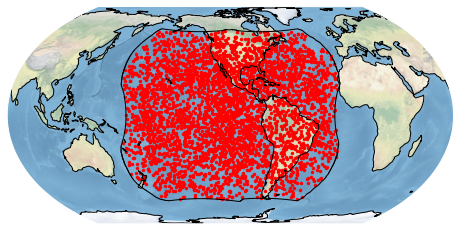

In [19]:
import matplotlib.pyplot as plt
bdf = BolideDataFrame(source='glm')
bdf.plot_detections(boundary='goes')
plt.show()

If you are familiar with matplotlib syntax, all of the same sorts of things work. Here is an example taking advantage of matplotlib:

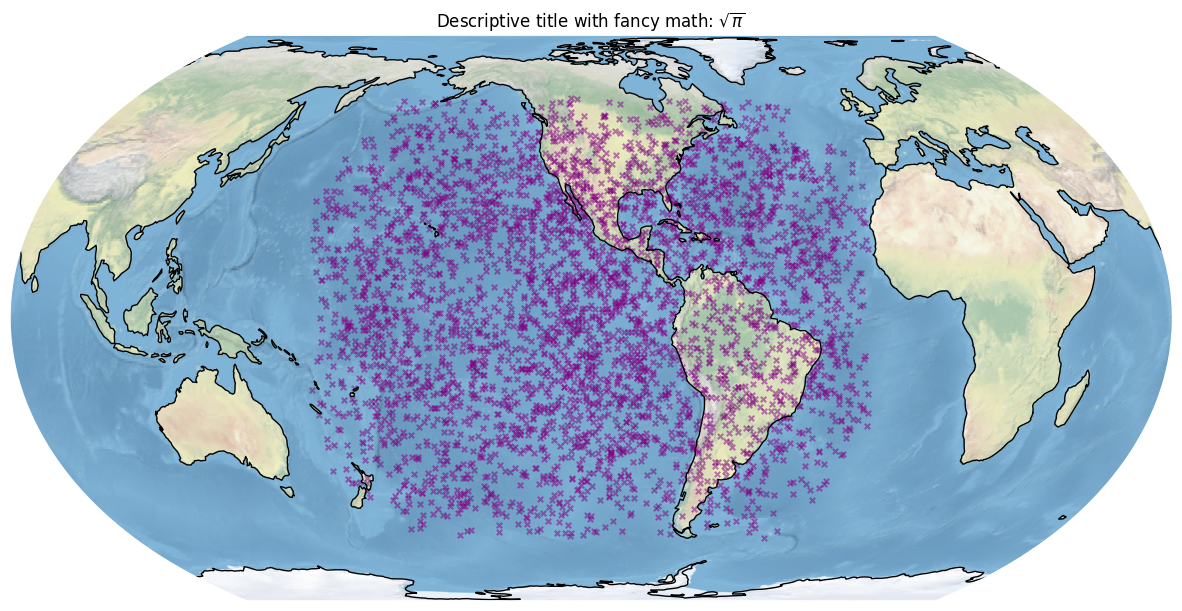

In [20]:
fig, ax = bdf.plot_detections(marker='x', alpha=0.5, color='purple', s=15, figsize=(15,9))
plt.title('Descriptive title with fancy math: $\sqrt{\pi}$')  # add a title
plt.savefig('descriptive-filename.png', dpi=300, bbox_inches='tight')  # save to disk
plt.show()

[Here](https://matplotlib.org/stable/tutorials/index.html) are some good tutorials on matplotlib.

If we only want to plot detections by GLM-17 and thus only really need the GOES-West position field-of-view boundary, we can do that as follows below. Note how we can filter and plot in the same line.

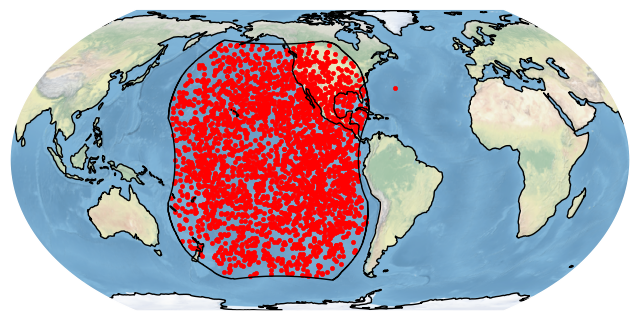

In [21]:
bdf[bdf.detectedBy.str.contains('GLM-17')].plot_detections(boundary='goes-w')
plt.show()

This shows us an interesting point in the Atlantic outside of the GOES-West GLM field-of-view. This is from when GOES-17 was not yet in the GOES-West position. If we only want points within the GOES-West GLM field-of-view, we can filter by field of view instead:

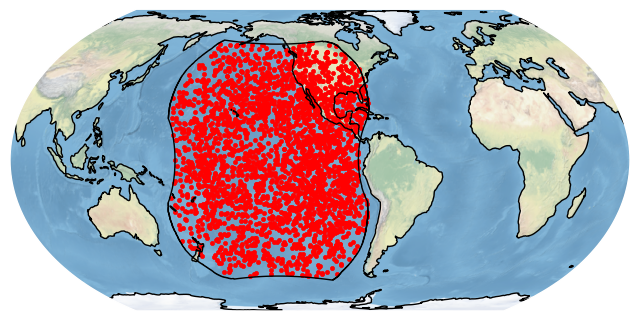

In [22]:
bdf.filter_boundary(boundary=['goes-w']).plot_detections(boundary='goes-w')
plt.show()

What if we don't like this map projection? `plot_detections` can accept any map projection in the form of a Cartopy CoordinateReferenceSystem object in the `crs` argument. Here is a map roughly from the perspective of GOES-16:

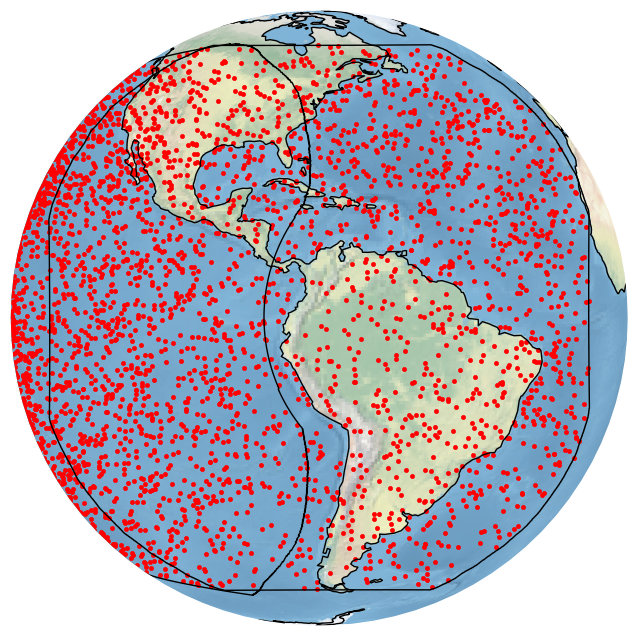

In [23]:
import cartopy.crs as ccrs
crs = ccrs.Geostationary(central_longitude = -75.2)
bdf.plot_detections(crs=crs, boundary=['goes-e','goes-w'])
plt.show()

We can get the same plot by using the built-in GOES_E CRS:

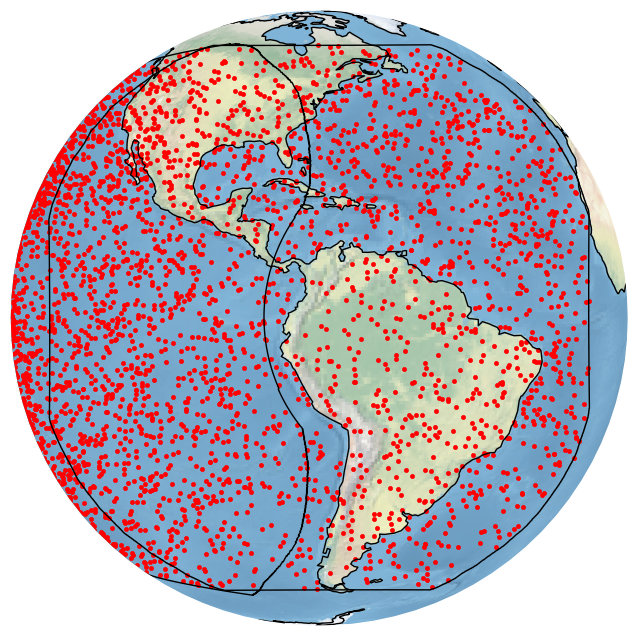

In [24]:
import bolides.crs as bcrs
bdf.plot_detections(crs=bcrs.GOES_E(), boundary=['goes-e','goes-w'])
plt.show()

[Here](https://scitools.org.uk/cartopy/docs/latest/reference/crs.html) is the documentation on CoordinateReferenceSystem objects, and [here](https://scitools.org.uk/cartopy/docs/latest/reference/projections.html) is a handy list of built-in projections. If you are really into map projections you can get some projections defined by an EPSG code using `ccrs.epsg`. Here is an example on the US National Atlas Equal Area projection (EPSG:2163):

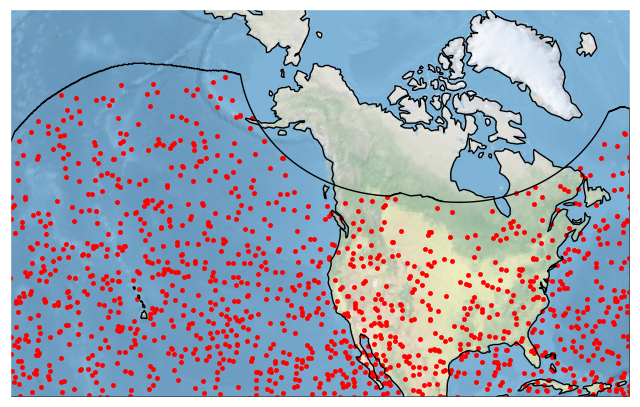

In [25]:
crs = ccrs.epsg(2163)
bdf.plot_detections(crs=crs, boundary='goes')
plt.show()

In the examples above, it would be nice to see which bolides were detected by which satellite. `plot_detections` handles automatic coloring of categorical data when a column name is passed in:

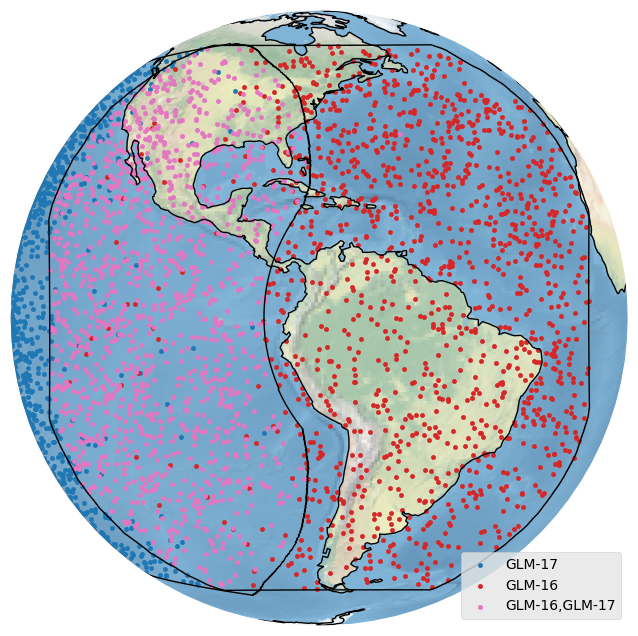

In [26]:
bdf.plot_detections(crs=bcrs.GOES_E(), category='detectedBy', boundary=['goes-e','goes-w'])
plt.show()

Neat. We can also plot quantitative data:

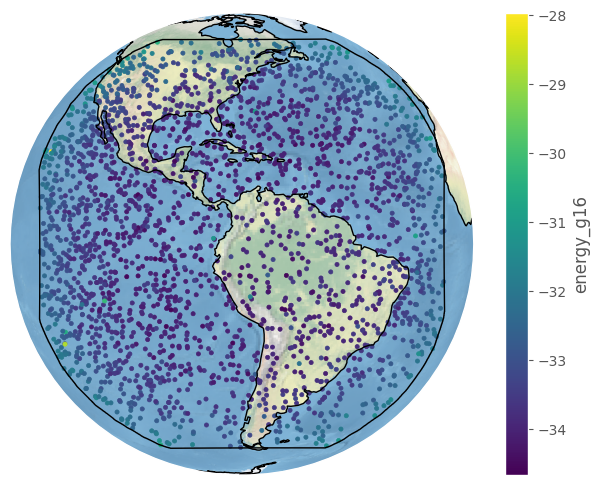

In [27]:
import numpy as np
fig, ax = bdf.plot_detections(crs=bcrs.GOES_E(), c=np.log(bdf.energy_g16), boundary='goes-e', figsize=(8,6))
plt.show()

The `BolideDataFrame` class is technically a subclass of the `GeoDataFrame` class from GeoPandas, so if you are familiar with it you can use their plotting methods too (see [here](https://geopandas.org/en/stable/docs/user_guide/mapping.html)).

We might also be interested in the density of bolides. The handy plot_density method will compute and plot this:

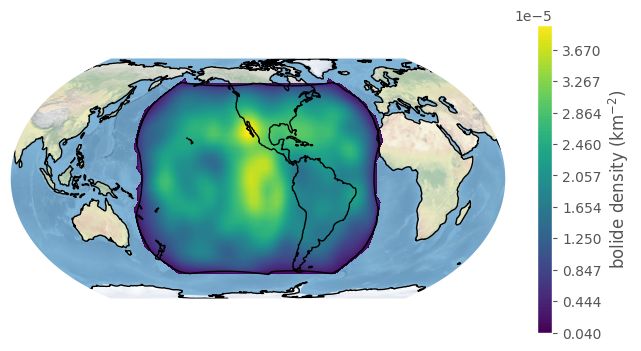

In [28]:
fig, ax = bdf.plot_density(boundary='goes', figsize=(8,4))
plt.show()

We can change the bandwidth argument to get a finer (and noisier!) density estimate:

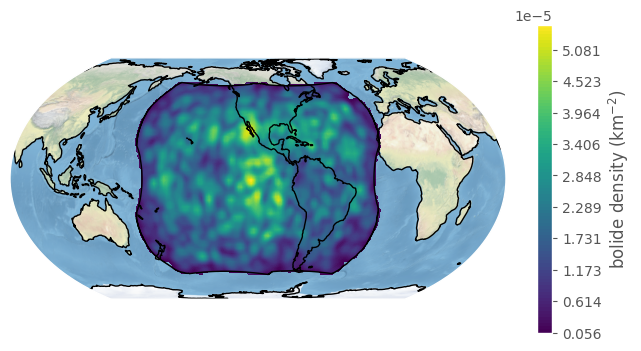

In [29]:
fig, ax = bdf.plot_density(bandwidth=2, lat_resolution=200, lon_resolution=100, boundary='goes', figsize=(8,4))
plt.show()

# Date Histograms

One useful visualization is the number of bolides detected at different dates. The `plot_dates` method handles this.

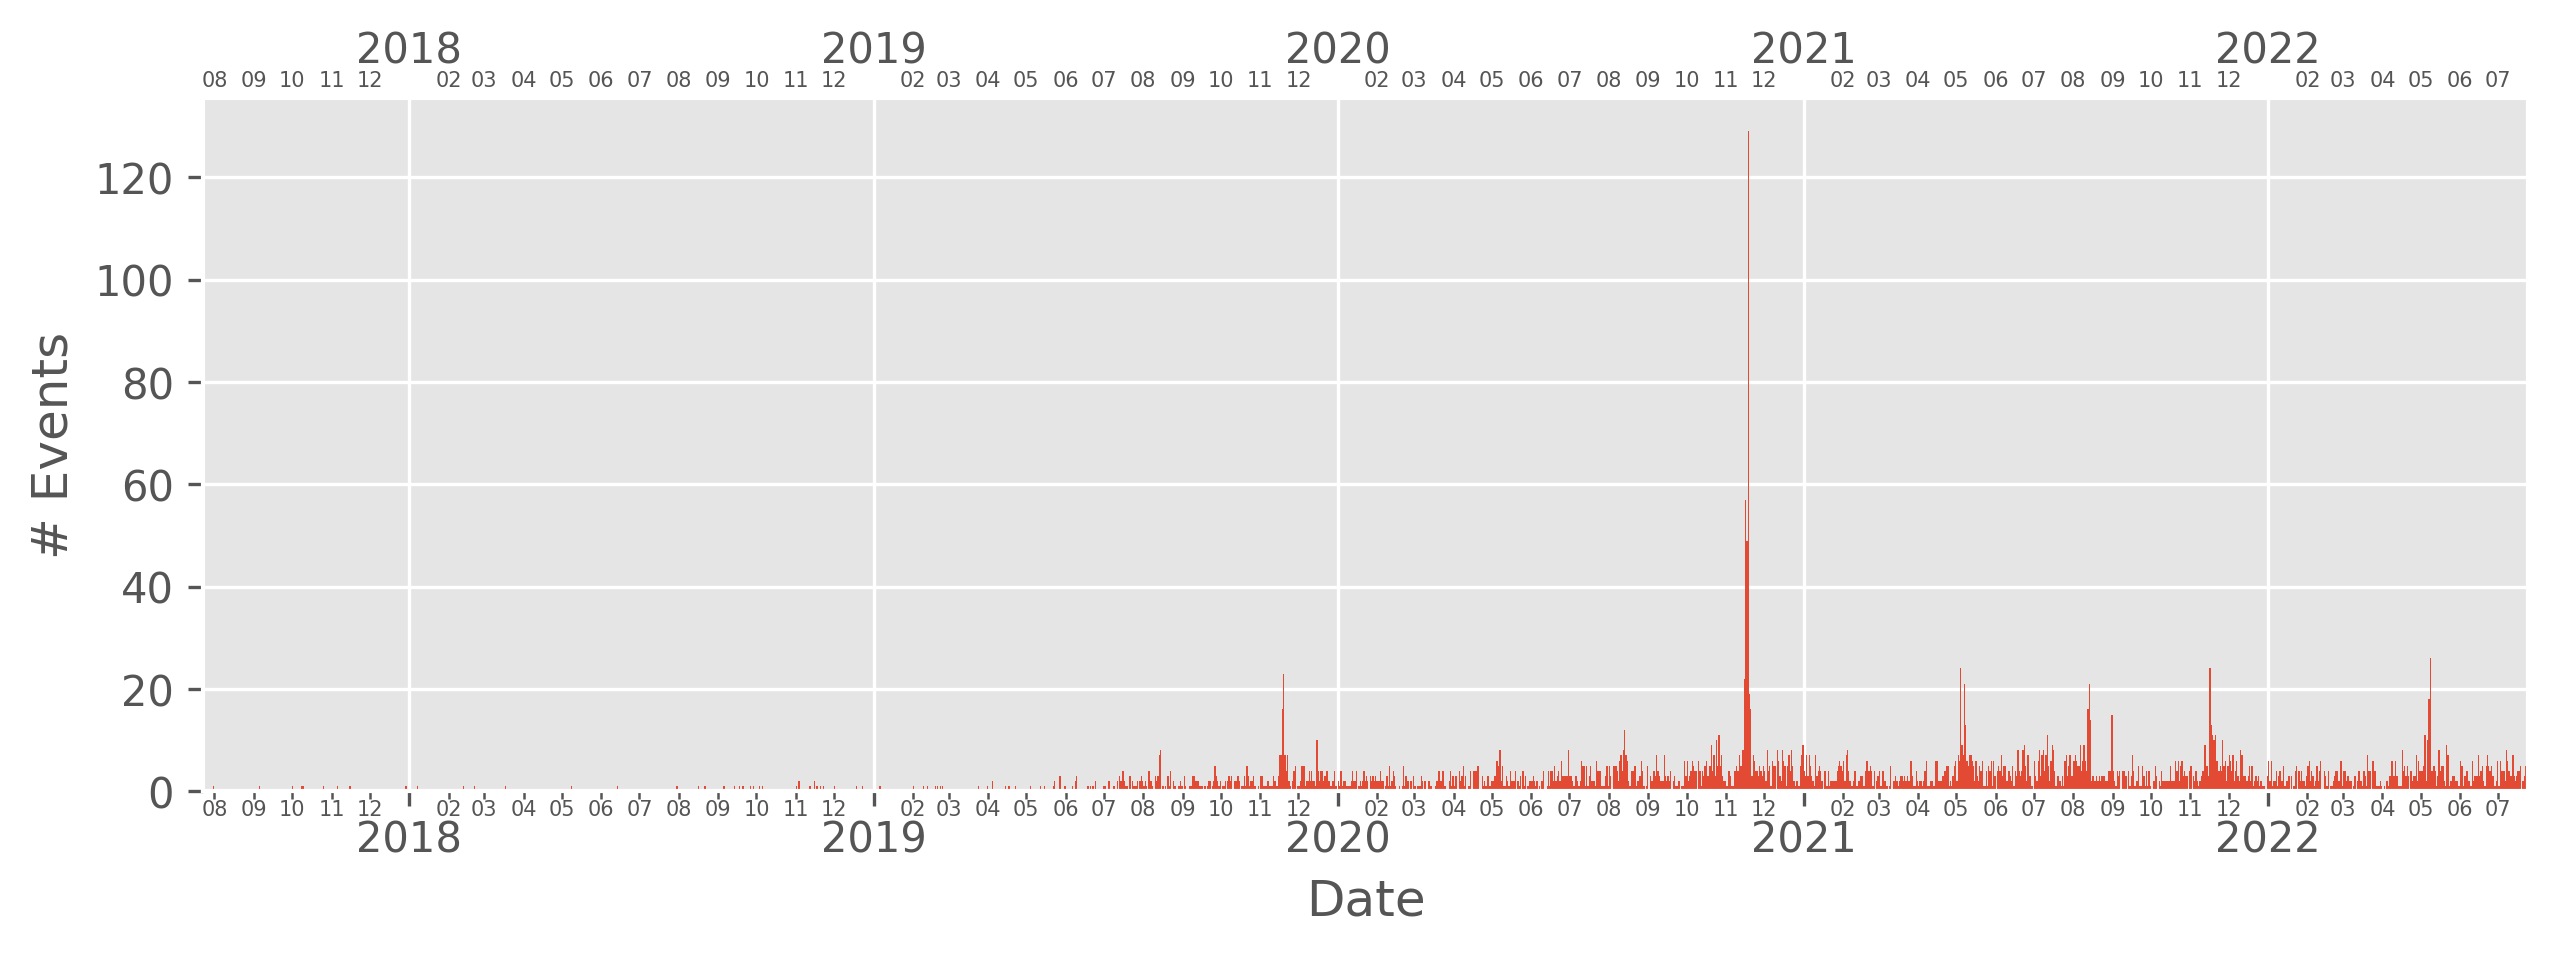

In [30]:
bdf.plot_dates()
plt.show()

Similar to `plot_detections`, regular matplotlib syntax works. If we are unhappy with the default style used by `bolides`, (ggplot), we can also pass in any [matplotlib style](https://matplotlib.org/stable/gallery/style_sheets/style_sheets_reference.html) into the style argument (This also works for `plot_detections`).

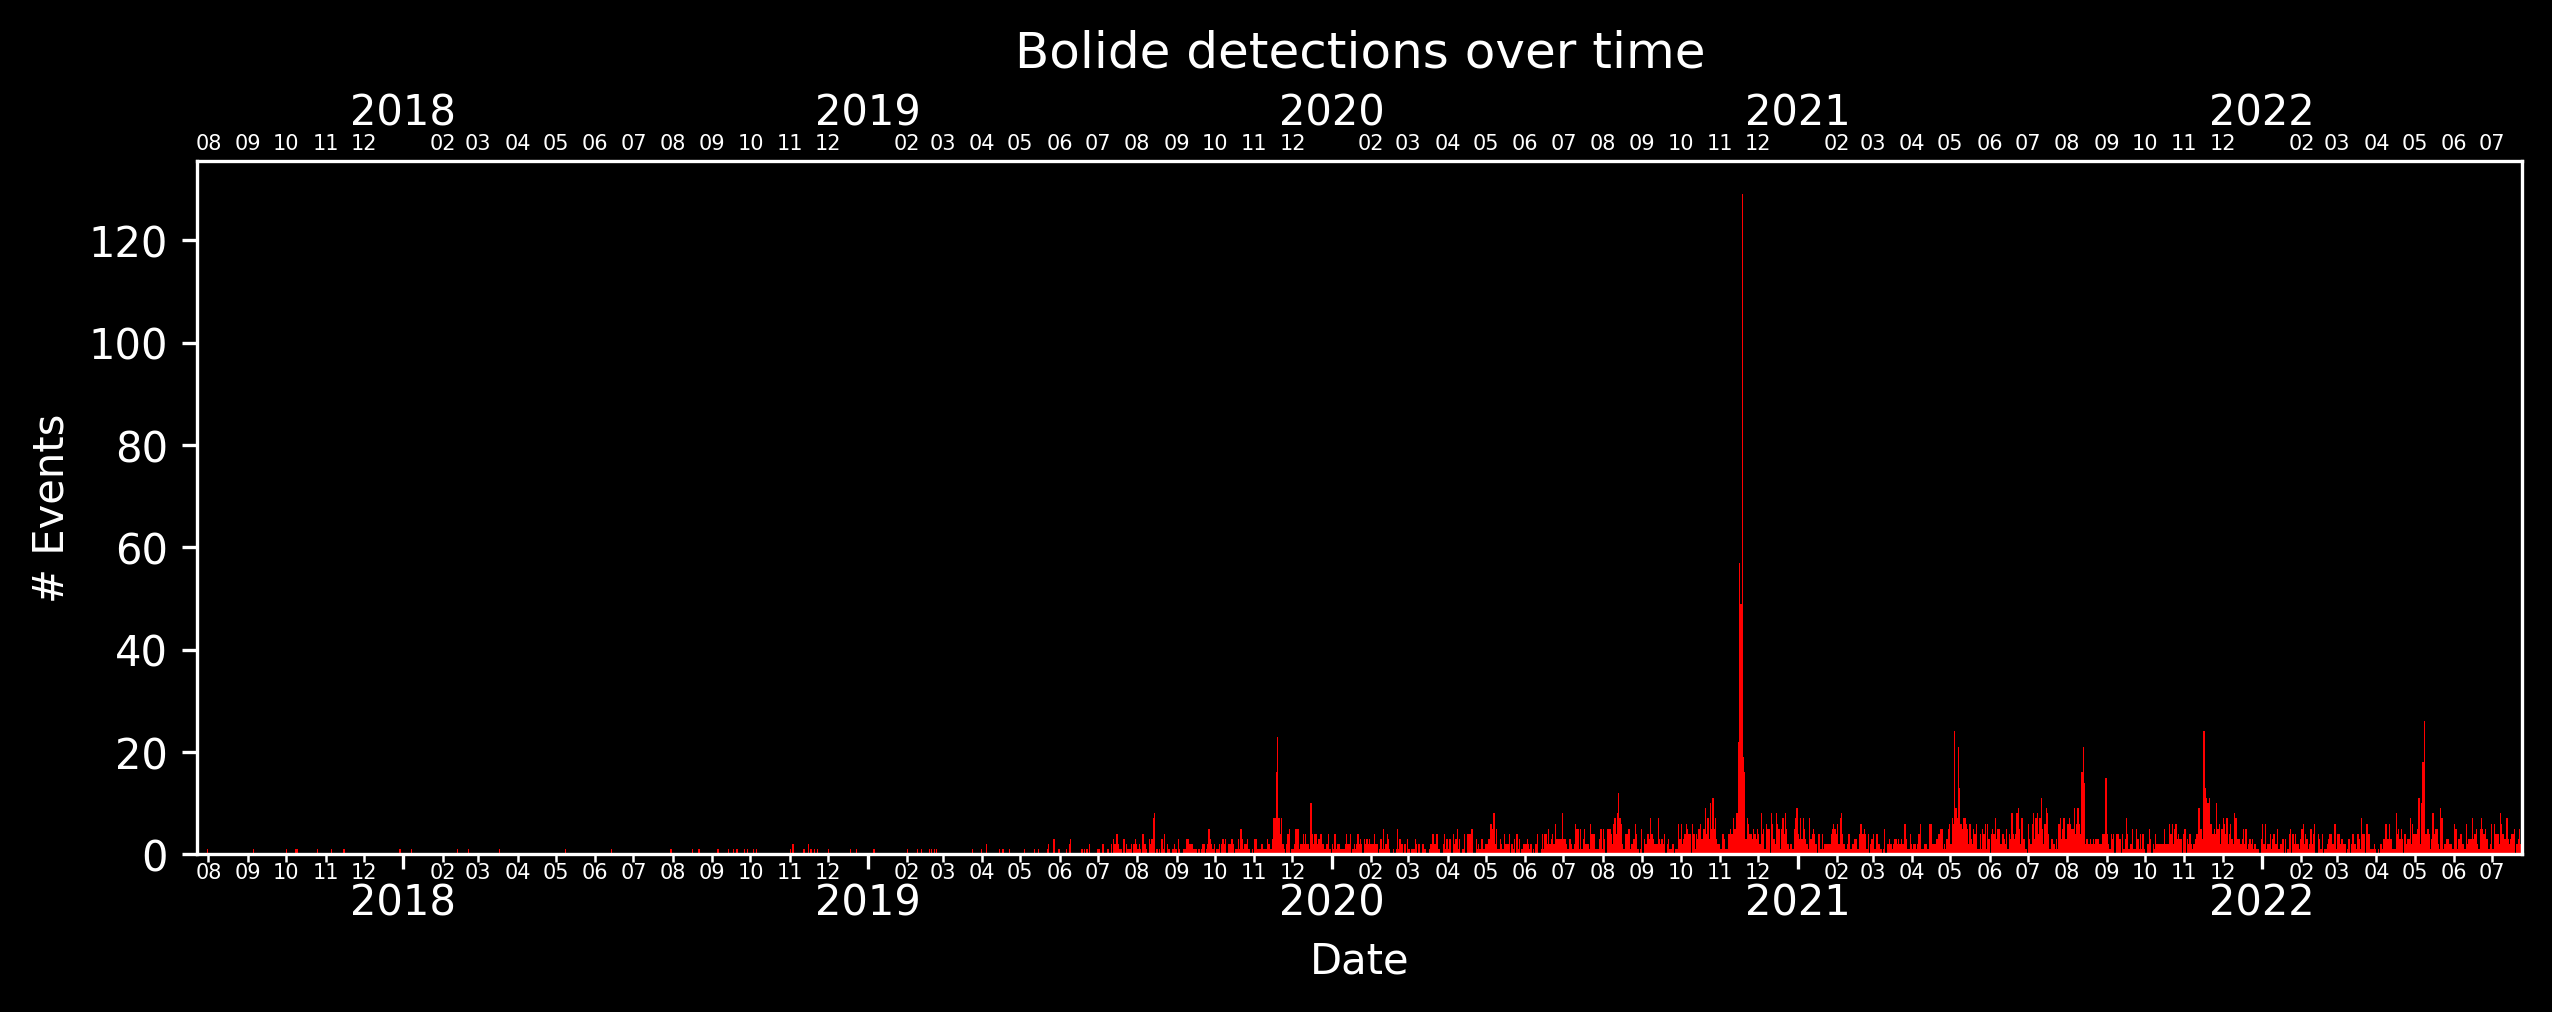

In [31]:
bdf.plot_dates(color='red', style='dark_background')
plt.title('Bolide detections over time')
plt.show()

 `plot_dates` also has a built-in date filter that works similarly to `filter_date`, and the frequency of the binning can be specified in the `freq` argument. The argument can take strings like "4D", "1Y", "3M", and so on. The `showers` argument also allows plotting the dates of meteor showers. Similar to `plot_detections`, we can also filter and plot in the same line.

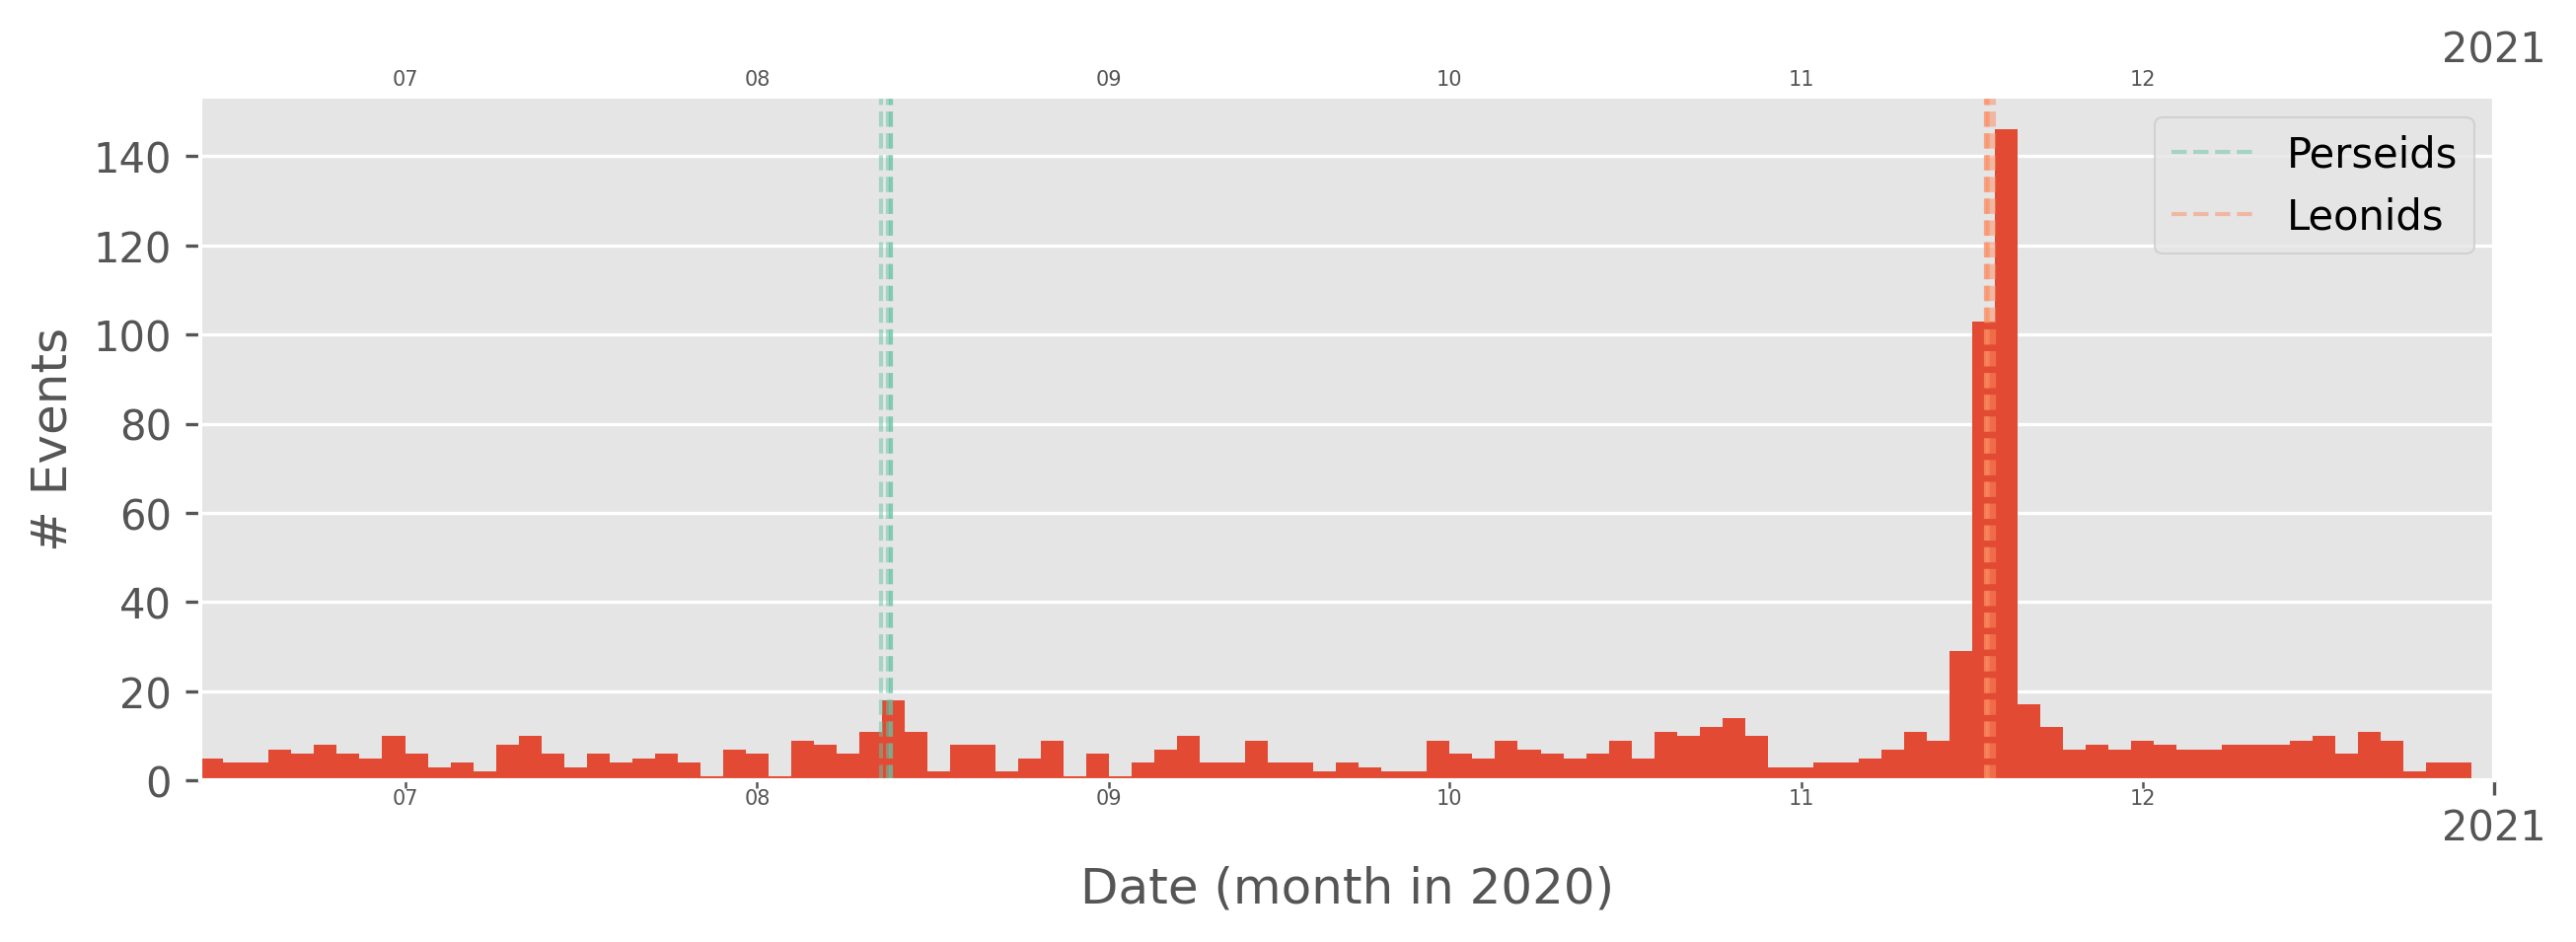

In [32]:
bdf[bdf.solarhour<12].plot_dates(freq="2D", start="2020-06-13", end="2021-01-01", showers=['LEO', 'PER'])
plt.show()

# Light curves

We also have data on bolide light curves, which can be interesting to look at. Let's first filter a small set of bolides to download light curves for:

In [33]:
bdf = BolideDataFrame(source='glm')
bdf = bdf.filter_date(start='2022-06-01',end='2022-06-13')

downloading: 9.43MiB [00:00, 54.2MiB/s]


Now we need to pull some data from the website:

In [34]:
bdf.add_website_data()

Exciting. Now we can plot light curves by accessing the `lightcurves` column:

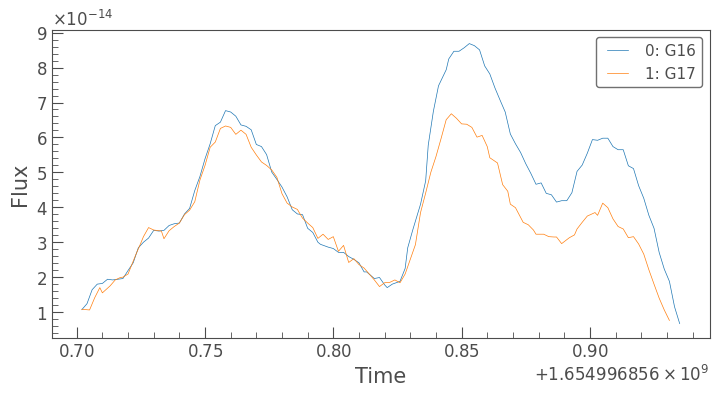

In [35]:
bdf.lightcurves.iloc[2].plot()
plt.show()

All of this is handled by the [lightkurve](http://docs.lightkurve.org/) package. The plots work similarly to `plot_detections` and `plot_dates` in that we can pass in regular matplotlib arguments.

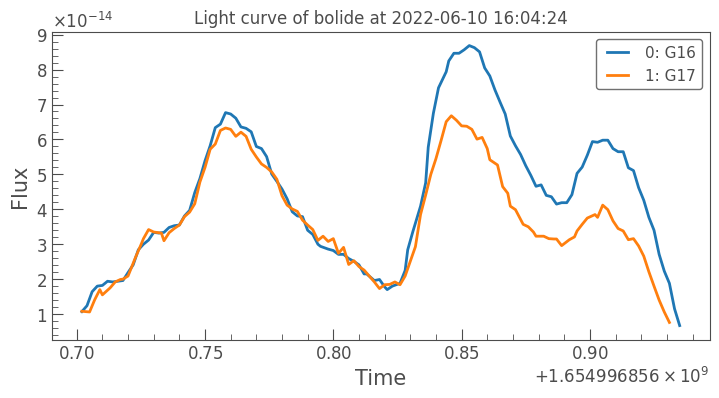

In [36]:
bdf.lightcurves.iloc[2].plot(linewidth=2)
plt.title('Light curve of bolide at '+str(bdf.datetime.iloc[6]))
plt.savefig(bdf._id.iloc[2] + '.png', dpi=300, bbox_inches='tight')
plt.show()

# Augmenting the data

`bolides` also supports automatically combining bolide data from multiple sources via the `augment` method. For instance, we may want to add USG data to GLM data to get additional information.

In [37]:
glm = BolideDataFrame(source='glm')
usg = BolideDataFrame(source='usg')

print("columns before augmentation:", len(glm.columns))
print("length before augmentation:", len(glm), 'bolides')

combined = glm.augment(usg)

print("columns after augmentation:", len(combined.columns))
print("length after augmentation:", len(combined), 'bolides')

downloading: 9.43MiB [00:00, 44.1MiB/s]
downloading: 79.2kiB [00:00, 1.20MiB/s]


columns before augmentation: 51
length before augmentation: 3927 bolides


Augmenting data: 100%|█████████████████████| 3927/3927 [00:14<00:00, 268.39it/s]

columns after augmentation: 71
length after augmentation: 3927 bolides


Note how the combined BolideDataFrame has more columns. These are coming from USG data. Columns ending in `_y` are the USG versions of those that existed in both data sets. Note how the length of the BolideDataFrame stays the same. This is because, by default `augment` keeps detections that only exist in the GLM data. If we instead want to only keep bolides that exist in both BolideDataFrames, we can use the `intersection` argument:

In [38]:
print(len(glm.augment(usg, intersection=True)), 'bolides')

Augmenting data: 100%|█████████████████████| 3927/3927 [00:15<00:00, 247.58it/s]

78 bolides


Here is some metadata about this notebook:

In [39]:
%watermark -uivm -p cartopy -rb

Last updated: 2022-08-07T22:52:54.627954-07:00

Python implementation: CPython
Python version       : 3.10.4
IPython version      : 8.4.0

cartopy: 0.20.3

Compiler    : GCC 11.2.0
OS          : Linux
Release     : 5.17.15-76051715-generic
Machine     : x86_64
Processor   : x86_64
CPU cores   : 8
Architecture: 64bit

Git repo: https://github.com/jcsmithhere/bolides.git

Git branch: bdf-implementation



In [40]:
!proj

Rel. 8.2.1, January 1st, 2022
usage: proj [-bdeEfiIlmorsStTvVwW [args]] [+opt[=arg] ...] [file ...]
